In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


In [20]:
df = pd.read_csv(r'gender_submission.csv')

In [21]:
df.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [22]:
print(df.isnull().sum())

PassengerId    0
Survived       0
dtype: int64


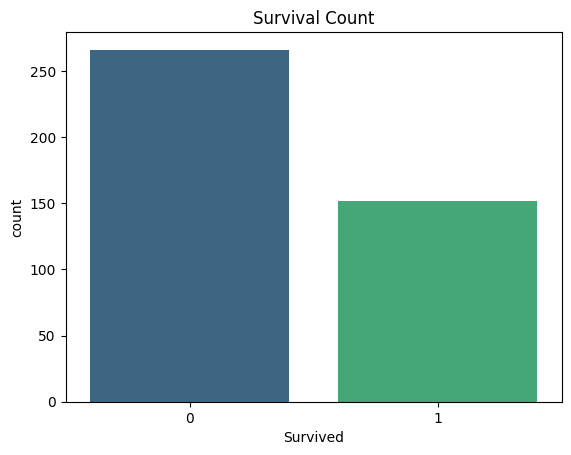

In [23]:
sns.countplot(data=df, x='Survived', palette='viridis')
plt.title('Survival Count')
plt.show()

In [49]:
def preprocess_data(df, is_train=True):
    # Fill missing values
    df["Age"].fillna(df["Age"].median(), inplace=True)
    df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
    df["Fare"].fillna(df["Fare"].median(), inplace=True)

    # Convert categorical variables
    df["Sex"] = df["Sex"].map({"male": 1, "female": 0})  # Encode Sex
    df["Embarked"] = df["Embarked"].map({"C": 0, "Q": 1, "S": 2})  # Encode Embarked

    # Drop PassengerId only for training data
    if is_train and "PassengerId" in df.columns:
        df = df.drop("PassengerId", axis=1)

    return df

# Apply preprocessing
train_data = preprocess_data(train_data)
test_data = preprocess_data(test_data, is_train=False)


In [51]:
X = train_data.drop("Survived", axis=1)
y = train_data["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [52]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [53]:
y_pred = model.predict(X_test)


In [54]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7318

Confusion Matrix:
 [[86 19]
 [29 45]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.82      0.78       105
           1       0.70      0.61      0.65        74

    accuracy                           0.73       179
   macro avg       0.73      0.71      0.72       179
weighted avg       0.73      0.73      0.73       179



In [57]:
test_predictions = model.predict(test_data)

In [62]:
print(test_predictions[:100])  


[0 0 1 1 1 0 0 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 1 1 0 1 1 1 0 0 1 0 0 1 1 0
 0 0 1 0 1 0 0 1 0 0 1 1 0 1 0 1 1 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0
 1 1 0 1 0 0 1 1 1 0 1 0 1 0 1 1 0 1 1 0 1 0 1 1 0 0]
